In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("../data/Nepali_News_dataset.csv")
df.head()

,title,text,category
0,‘मंगल यात्रा’ को आशा जगाउने ‘स्टारसिप’,काठमाडौँ — अमेरिकी अर्बपति इलन मस्कको कम्पनी स...,Feature
1,पप सम्राट्को दोस्रो ‘इनिङ’,काठमाडौँ — त्यतिबेला पपलाई गफ भनिन्थ्यो । पश्च...,Feature
2,आठ आरोही जन्माउने किमजुङ,काठमाडौँ — उनलाई के लाग्छ भने– जीवन आफैंमा एक ...,Feature
3,ब्याट नं. ३८ का अब्बल अधिकृत,काठमाडौँ — नेपाल सरकारको अधिकृत ‘ब्याट–३८’ (बे...,Feature
4,दैनिक जीवनको एक हिस्सा ‘हाम्रो पात्रो’,काठमाडौँ — केही समययता नेपालमा सूचना प्रविधि क...,Feature


In [3]:
df.shape

(70769, 3)

In [4]:
df.columns

Index(['title', 'text', 'category'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70769 entries, 0 to 70768
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     70769 non-null  str  
 1   text      70769 non-null  str  
 2   category  70769 non-null  str  
dtypes: str(3)
memory usage: 1.6 MB


In [6]:
df.isnull().sum()

title       0
text        0
category    0
dtype: int64

In [7]:
df['category'].value_counts()

category
News             36798
Sports           18767
Others            7258
Opinion           2358
Entertainment     2144
Feature           2014
Diaspora           750
World              462
Education          188
Blog                30
Name: count, dtype: int64

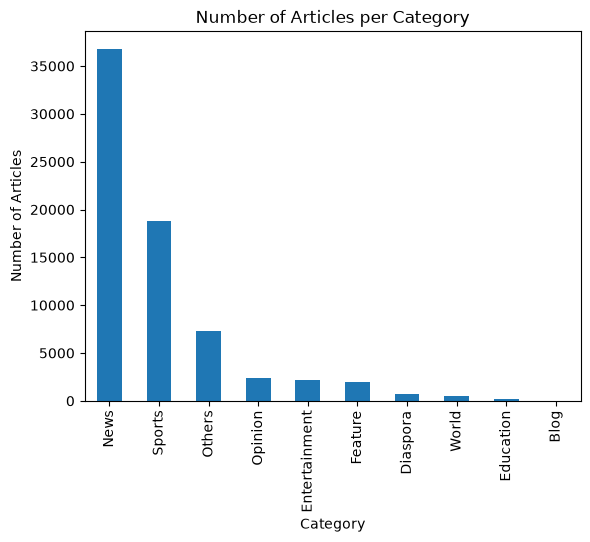

In [8]:
df['category'].value_counts().plot(kind='bar')

plt.title('Number of Articles per Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')

plt.show()

In [9]:
selected_categories =['Sports', 'Opinion', 'Entertainment', 'Feature']

In [10]:
df_selected= df[df['category'].isin(selected_categories)]

In [11]:
df_selected['category'].value_counts()

category
Sports           18767
Opinion           2358
Entertainment     2144
Feature           2014
Name: count, dtype: int64

In [12]:
balanced_df = (
    df_selected
    .groupby('category')
    .sample(n=2000, random_state=42)
)

In [13]:
balanced_df['category'].value_counts()

category
Entertainment    2000
Feature          2000
Opinion          2000
Sports           2000
Name: count, dtype: int64

In [14]:
balanced_df.columns

Index(['title', 'text', 'category'], dtype='str')

In [15]:
balanced_df.shape

(8000, 3)

In [16]:
balanced_df.iloc[0]

title                                   बाहुबलीको ‘बिग गिफ्ट’
text        मुम्बई — बाहुबली नायक प्रभासले आफ्ना जिम ट्रेन...
category                                        Entertainment
Name: 8431, dtype: str

In [17]:
balanced_df.isnull().sum()

title       0
text        0
category    0
dtype: int64

In [18]:
balanced_df['combined_text'] = (
    balanced_df['title'] + ' ' + balanced_df['text']
)

In [19]:
balanced_df[['title', 'text', 'combined_text', 'category']].head(3)

,title,text,combined_text,category
8431,बाहुबलीको ‘बिग गिफ्ट’,मुम्बई — बाहुबली नायक प्रभासले आफ्ना जिम ट्रेन...,बाहुबलीको ‘बिग गिफ्ट’ मुम्बई — बाहुबली नायक प्...,Entertainment
9021,सिने स्टार टोरन्टोमा,काठमाडौँ — नेपाली फिल्म र फिल्मकर्मीलाई विश्वस...,सिने स्टार टोरन्टोमा काठमाडौँ — नेपाली फिल्म र...,Entertainment
7215,सगरमाथाको फेदमा रियालिटी शो,काठमाडौँ — इन्टरनेटको माध्यमबाट सिधै दर्शकसामु...,सगरमाथाको फेदमा रियालिटी शो काठमाडौँ — इन्टरने...,Entertainment


In [20]:
X = balanced_df['combined_text']
y = balanced_df['category']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6400,)
Testing data: (1600,)


In [23]:
print("Training categories:")
print(y_train.value_counts())

print("\nTesting categories:")
print(y_test.value_counts())

Training categories:
category
Opinion          1600
Feature          1600
Sports           1600
Entertainment    1600
Name: count, dtype: int64

Testing categories:
category
Sports           400
Opinion          400
Feature          400
Entertainment    400
Name: count, dtype: int64


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [25]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (6400, 18093)
Testing TF-IDF shape: (1600, 18093)


# Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [27]:
y_pred_logistic = logistic_model.predict(X_test_tfidf)
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_logistic
})

comparison.head(10)

,Actual,Predicted
0,Sports,Sports
1,Opinion,Opinion
2,Feature,Entertainment
3,Feature,Feature
4,Entertainment,Entertainment
5,Feature,Feature
6,Feature,Entertainment
7,Sports,Sports
8,Opinion,Opinion
9,Opinion,Opinion


In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.914375
               precision    recall  f1-score   support

Entertainment       0.92      0.89      0.90       400
      Feature       0.85      0.86      0.86       400
      Opinion       0.92      0.94      0.93       400
       Sports       0.97      0.96      0.97       400

     accuracy                           0.91      1600
    macro avg       0.91      0.91      0.91      1600
 weighted avg       0.91      0.91      0.91      1600



In [29]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print(cm_logistic)

[[357  37   2   4]
 [ 25 346  26   3]
 [  4  18 375   3]
 [  4   8   3 385]]


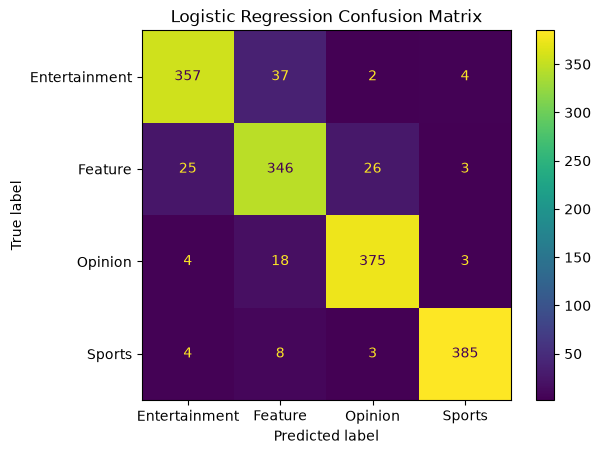

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

* TF-IDF combined with Logistic Regression achieved 91.44% accuracy and a macro F1-score of approximately 0.91 on the balanced four-category Nepali news classification dataset.

# Multinomial Naive Bayes

In [31]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.844375
               precision    recall  f1-score   support

Entertainment       0.95      0.72      0.82       400
      Feature       0.71      0.83      0.76       400
      Opinion       0.80      0.95      0.87       400
       Sports       0.99      0.88      0.93       400

     accuracy                           0.84      1600
    macro avg       0.86      0.84      0.85      1600
 weighted avg       0.86      0.84      0.85      1600



* In the initial experiments, Logistic Regression outperformed Multinomial Naive Bayes on the balanced four-category Nepali news classification task. Logistic Regression achieved 91.44% accuracy and a macro F1-score of approximately 0.91, compared with 84.44% accuracy and a macro F1-score of approximately 0.85 for Multinomial Naive Bayes.

# Linear Support Vector Machine

In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", accuracy_svm)
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.923125
               precision    recall  f1-score   support

Entertainment       0.92      0.91      0.91       400
      Feature       0.86      0.87      0.86       400
      Opinion       0.95      0.94      0.94       400
       Sports       0.97      0.97      0.97       400

     accuracy                           0.92      1600
    macro avg       0.92      0.92      0.92      1600
 weighted avg       0.92      0.92      0.92      1600



In [33]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Multinomial Naive Bayes',
        'Linear SVM'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_nb,
        accuracy_svm
    ]
})

results['Accuracy (%)'] = results['Accuracy'] * 100

results


,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.914375,91.4375
1,Multinomial Naive Bayes,0.844375,84.4375
2,Linear SVM,0.923125,92.3125


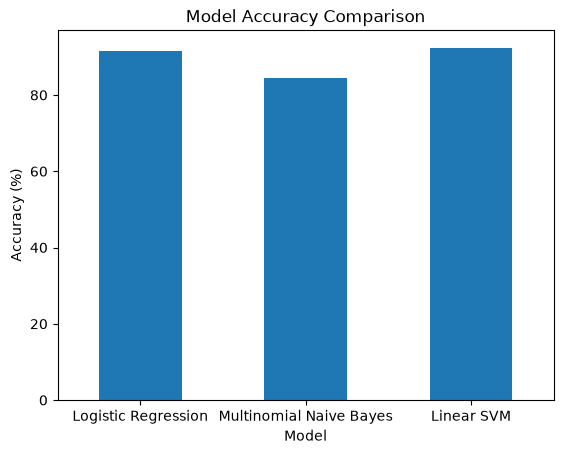

In [34]:
results.plot(
    x='Model',
    y='Accuracy (%)',
    kind='bar',
    legend=False
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=0)

plt.show()

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[363  34   0   3]
 [ 27 348  20   5]
 [  2  18 377   3]
 [  4   6   1 389]]


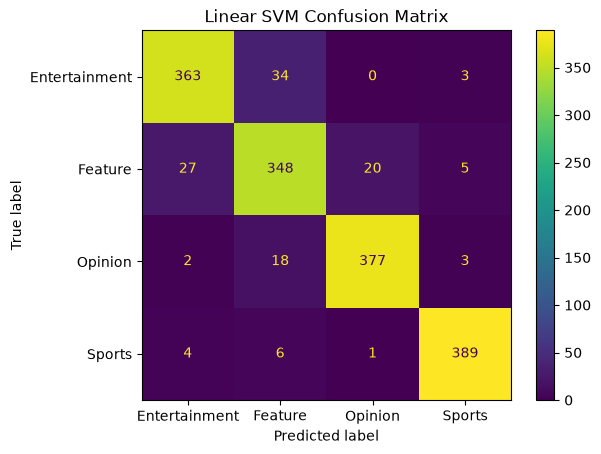

In [36]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)

plt.title("Linear SVM Confusion Matrix")
plt.show()

In [37]:
errors = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': y_pred_svm
})

errors = errors[errors['actual'] != errors['predicted']]

errors.head(10)

,text,actual,predicted
2,यसरी तयार भयो 'कालो केशमा रेलिमई...' काठमाडौँ ...,Feature,Entertainment
6,‘फिल्म मनोरञ्जन मात्रै होइन’ [भिडियो] काठमाडौँ...,Feature,Entertainment
13,मिस्टर र मिस थारुमा ३२ प्रतिस्पर्धी (मोरङ) — म...,Entertainment,Sports
24,सगरमाथालाई आराम दिऔं १९५३ मे २९ का दिन न्युजिल...,Opinion,Feature
44,बीपी : अध्यात्म र बौद्धिकताको सन्दर्भ बौद्धिक ...,Feature,Opinion
49,लैंगिक विभेदविरुद्ध नेता बनेकी जेनी बार्सिलोना...,Sports,Feature
65,टोलपिच्छे कृषक पाठशाला डडेलधुरा — गाउँमा कृषि ...,Feature,Entertainment
73,पेबल आर्टमा ‘क्रिएसन’ बागलुङ — झन्डै ६ फिट अग्...,Entertainment,Feature
78,आरडीटी किटबारे विवाद किन ? (एक्सप्लेनर) काठमाड...,Feature,Sports
81,"कविता, चित्र, कोलाज र कालजयी सिनेमा काठमाडौँ —...",Feature,Opinion


In [38]:
print("Total incorrect predictions:", len(errors))

Total incorrect predictions: 123


In [39]:
error_patterns = errors.groupby(
    ['actual', 'predicted']
).size().sort_values(ascending=False)

print(error_patterns)

actual         predicted    
Entertainment  Feature          34
Feature        Entertainment    27
               Opinion          20
Opinion        Feature          18
Sports         Feature           6
Feature        Sports            5
Sports         Entertainment     4
Entertainment  Sports            3
Opinion        Sports            3
               Entertainment     2
Sports         Opinion           1
dtype: int64


* Inspection of actual misclassified articles

In [40]:
entertainment_feature_errors = errors[
    (errors['actual'] == 'Entertainment') &
    (errors['predicted'] == 'Feature')
]

entertainment_feature_errors[['text', 'actual', 'predicted']].head(5)

,text,actual,predicted
73,पेबल आर्टमा ‘क्रिएसन’ बागलुङ — झन्डै ६ फिट अग्...,Entertainment,Feature
93,हालखबर : झन् हँसिला मदनकृष्ण काठमाडौँ — अघिल्ल...,Entertainment,Feature
101,'एक दिन मिस वर्ल्डको क्राउन पनि पक्कै आउला' [भ...,Entertainment,Feature
167,लैचा छाडेर मेहन्दी काठमाडौँ — सहरका दरबार स्क्...,Entertainment,Feature
230,दसैं गीतमा परदेश पीडा काठमाडौँ — दसैं सुरु भइस...,Entertainment,Feature


In [41]:
feature_entertainment_errors = errors[
    (errors['actual'] == 'Feature') &
    (errors['predicted'] == 'Entertainment')
]

feature_entertainment_errors[['text', 'actual', 'predicted']].head(5)

,text,actual,predicted
2,यसरी तयार भयो 'कालो केशमा रेलिमई...' काठमाडौँ ...,Feature,Entertainment
6,‘फिल्म मनोरञ्जन मात्रै होइन’ [भिडियो] काठमाडौँ...,Feature,Entertainment
65,टोलपिच्छे कृषक पाठशाला डडेलधुरा — गाउँमा कृषि ...,Feature,Entertainment
283,नौटंकीलाई जीवन न कुनै नाटकघर । न त कतै स्थायी ...,Feature,Entertainment
495,कर्मा पछ्याउँदै कुन्दन काठमाडौँ — भाइ कुन्दनला...,Feature,Entertainment


In [42]:
feature_opinion_errors = errors[
    (errors['actual'] == 'Feature') &
    (errors['predicted'] == 'Opinion')
]

feature_opinion_errors[['text', 'actual', 'predicted']].head(5)

,text,actual,predicted
44,बीपी : अध्यात्म र बौद्धिकताको सन्दर्भ बौद्धिक ...,Feature,Opinion
81,"कविता, चित्र, कोलाज र कालजयी सिनेमा काठमाडौँ —...",Feature,Opinion
86,नारी दिवस विशेष: बलात्कारको तथ्य र मिथ्या काठम...,Feature,Opinion
159,उद्यमशील नारी काठमाडौं — साना तथा घरेलु उद्यमी...,Feature,Opinion
257,कसरी सुधार्ने शिक्षाको स्तर ? काठमाडौँ — मुलुक...,Feature,Opinion


* Error analysis showed that the Linear SVM most frequently confused Entertainment and Feature articles, followed by confusion between Feature and Opinion. This suggests that these categories may contain overlapping vocabulary, topics, or writing styles. In contrast, Sports articles were rarely confused with other categories, indicating that the category contains more distinctive textual patterns in the selected dataset.

# inspection of the vocabulary learned by the model

In [43]:
feature_names = vectorizer.get_feature_names_out()

feature_names[:20]

array(['000', '000अब', '000अर', '000एक', '000एसएलस', '000क', '000झ',
       '000त', '000न', '000भ', '000भद', '000म', '000मनभ', '000य', '000यस',
       '000र', '000स', '000सद', '000सध', '000सन'], dtype=object)

In [44]:
svm_model.classes_

array(['Entertainment', 'Feature', 'Opinion', 'Sports'], dtype=object)

In [45]:
import numpy as np

for i, category in enumerate(svm_model.classes_):
    
    top_indices = np.argsort(svm_model.coef_[i])[-10:]
    
    top_words = feature_names[top_indices]
    
    print(f"\nTop words for {category}:")
    print(top_words)


Top words for Entertainment:
['बत' 'वजन' 'ठम' 'टकल' 'उडम' 'मम' 'अभ' 'फत' 'कन' 'चलच']

Top words for Feature:
['पढ' 'कड' 'यह' 'पसल' 'रवद' 'इरफ' 'सगर' 'भन' 'वट' 'उनक']

Top words for Opinion:
['अत' 'कत' 'दलहर' '२०७८' 'तसर' '२०७९' 'पय' 'सक' 'यस' 'यसर']

Top words for Sports:
['यसम' 'रह' 'लबक' 'यनस' 'घक' 'रश' 'लक' 'रन' 'गश' 'टबल']


* Improve TF-IDF tokenization for Nepali text

In [46]:
print(X_train.iloc[0])

जर्मनीको संघीयताबाट नेपाललाई शिक्षा जर्मनीमा माथिल्लो सदनलाई बुन्डेसराट र तल्लो सदनलाई बुन्डेस्टाग भनिन्छ । सरकारले सबभन्दा पहिला विधेयक माथिल्लो सदनमा पेस गर्नुपर्ने संवैधानिक व्यवस्था छ (धारा ७६) । माथिल्लो सदनमा प्रदेश (ल्यान्डर) को मात्र बाहुल्य छ । जर्मनीको संघीयतालाई नजिकबाट नियाल्न मलाई माथिल्लो सदनको दह्रो भूमिकाका कारण घचघच्याइरहेको थियो । तिहारअगाडि जर्मनीको एउटा विश्वविद्यालयको निमन्त्रणाले मलाई त्यस्तो अवसर दियो ।बर्लिनस्थित फ्री विश्वविद्यालयका विद्यार्थीहरूका लागि विकेन्द्रीकरण, संघीयता र नेपालको शासन व्यवस्थाबारे प्रवचन दिने अवसर पनि जुट्यो । जर्मन संघीयतालगायतका विषयमा माथिल्लो सदन र तल्लो सदनका पदाधिकारीहरू, पोट्सडाम र फ्री विश्वविद्यालयका करिब एक दर्जन प्राध्यापकलगायतसँग मैले छलफल र अन्तरक्रिया पनि गरें । यसै सन्दर्भमा यहाँ जर्मनीको संघीयताका केही आयामबारे चर्चा गरिएको छ ।जर्मनीको संसद् नेपालकै जस्तो द्विसदनात्मक छ । सरकारको निर्माण पनि नेपालकै जस्तै तल्लो सदनले मात्र गर्छ । हरेक चार वर्षमा यसको निर्वाचन हुन्छ । कार्यकाल सकिनुभन्दा दुई महिनाअगाडि नै यसको निर्वाचन गर्न

In [47]:
import re

sample_text = X_train.iloc[0]

tokens = re.findall(r'\w+', sample_text)

print(tokens[:50])

['जर', 'मन', 'क', 'स', 'घ', 'यत', 'ब', 'ट', 'न', 'प', 'लल', 'ई', 'श', 'क', 'ष', 'जर', 'मन', 'म', 'म', 'थ', 'ल', 'ल', 'सदनल', 'ई', 'ब', 'न', 'ड', 'सर', 'ट', 'र', 'तल', 'ल', 'सदनल', 'ई', 'ब', 'न', 'ड', 'स', 'ट', 'ग', 'भन', 'न', 'छ', 'सरक', 'रल', 'सबभन', 'द', 'पह', 'ल', 'व']


* Test whitespace tokenization

In [48]:
sample_text = X_train.iloc[0]

tokens = sample_text.split()

print(tokens[:50])

['जर्मनीको', 'संघीयताबाट', 'नेपाललाई', 'शिक्षा', 'जर्मनीमा', 'माथिल्लो', 'सदनलाई', 'बुन्डेसराट', 'र', 'तल्लो', 'सदनलाई', 'बुन्डेस्टाग', 'भनिन्छ', '।', 'सरकारले', 'सबभन्दा', 'पहिला', 'विधेयक', 'माथिल्लो', 'सदनमा', 'पेस', 'गर्नुपर्ने', 'संवैधानिक', 'व्यवस्था', 'छ', '(धारा', '७६)', '।', 'माथिल्लो', 'सदनमा', 'प्रदेश', '(ल्यान्डर)', 'को', 'मात्र', 'बाहुल्य', 'छ', '।', 'जर्मनीको', 'संघीयतालाई', 'नजिकबाट', 'नियाल्न', 'मलाई', 'माथिल्लो', 'सदनको', 'दह्रो', 'भूमिकाका', 'कारण', 'घचघच्याइरहेको', 'थियो', '।']


* Creating an improved Nepali-aware TF-IDF vectorizer using whitespace tokenization

In [49]:
nepali_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None
)

* Fitting the improved vectorizer on training data

In [50]:
X_train_tfidf_nepali = nepali_vectorizer.fit_transform(X_train)

* Transform the test data

In [51]:
X_test_tfidf_nepali = nepali_vectorizer.transform(X_test)

* Checking the vocabulary

In [52]:
nepali_feature_names = nepali_vectorizer.get_feature_names_out()

print(nepali_feature_names[:30])

['!' '!!' '!!’त्यो' "!'" "!'अटल" "!'उनले" "!'कतिपय" "!'कस्तो" "!'केही"
 "!'क्यासेट" "!'गुन्योचोलो'बाटै" "!'घरभन्दा" "!'त्यतिकैमा" "!'दर्शकलाई"
 "!'दीर्घले" "!'बाख्रा" "!'बुढो" "!'भुवनको" "!'यही" "!'यी" "!'हप्ता"
 '!(कान्तिपुरसँगको' '!(राजनीति' '!(लेखक' '!(शनिबार' '!)' "!,'" '!,’'
 '!vidhyapati@gmail.comभुटान' '!अधमरो']


In [53]:
print("Training shape:", X_train_tfidf_nepali.shape)
print("Testing shape:", X_test_tfidf_nepali.shape)

Training shape: (6400, 332307)
Testing shape: (1600, 332307)


* Creating a simple Nepali text tokenizer that splits text by whitespace, removes punctuation from the beginning and end of tokens and keeps the Nepali word itself.

In [54]:
import string

def nepali_tokenizer(text):
    tokens = text.split()
    
    cleaned_tokens = []
    
    for token in tokens:
        cleaned = token.strip(string.punctuation + "।“”‘’—–…")
        
        if cleaned:
            cleaned_tokens.append(cleaned)
    
    return cleaned_tokens

In [55]:
sample_text = X_train.iloc[0]

cleaned_tokens = nepali_tokenizer(sample_text)

print(cleaned_tokens[:50])

['जर्मनीको', 'संघीयताबाट', 'नेपाललाई', 'शिक्षा', 'जर्मनीमा', 'माथिल्लो', 'सदनलाई', 'बुन्डेसराट', 'र', 'तल्लो', 'सदनलाई', 'बुन्डेस्टाग', 'भनिन्छ', 'सरकारले', 'सबभन्दा', 'पहिला', 'विधेयक', 'माथिल्लो', 'सदनमा', 'पेस', 'गर्नुपर्ने', 'संवैधानिक', 'व्यवस्था', 'छ', 'धारा', '७६', 'माथिल्लो', 'सदनमा', 'प्रदेश', 'ल्यान्डर', 'को', 'मात्र', 'बाहुल्य', 'छ', 'जर्मनीको', 'संघीयतालाई', 'नजिकबाट', 'नियाल्न', 'मलाई', 'माथिल्लो', 'सदनको', 'दह्रो', 'भूमिकाका', 'कारण', 'घचघच्याइरहेको', 'थियो', 'तिहारअगाडि', 'जर्मनीको', 'एउटा', 'विश्वविद्यालयको']


In [56]:
nepali_clean_vectorizer = TfidfVectorizer(
    tokenizer=nepali_tokenizer,
    token_pattern=None
)

In [57]:
X_train_tfidf_clean = nepali_clean_vectorizer.fit_transform(X_train)

X_test_tfidf_clean = nepali_clean_vectorizer.transform(X_test)

In [58]:
print("Training shape:", X_train_tfidf_clean.shape)
print("Testing shape:", X_test_tfidf_clean.shape)

Training shape: (6400, 265714)
Testing shape: (1600, 265714)


* Training Linear SVM after the improved preprocessing

In [59]:
svm_clean_model = LinearSVC()

svm_clean_model.fit(X_train_tfidf_clean, y_train)

y_pred_svm_clean = svm_clean_model.predict(X_test_tfidf_clean)

accuracy_svm_clean = accuracy_score(
    y_test,
    y_pred_svm_clean
)

print("Clean Nepali TF-IDF + Linear SVM Accuracy:", accuracy_svm_clean)

print(classification_report(
    y_test,
    y_pred_svm_clean
))

Clean Nepali TF-IDF + Linear SVM Accuracy: 0.941875
               precision    recall  f1-score   support

Entertainment       0.93      0.93      0.93       400
      Feature       0.90      0.88      0.89       400
      Opinion       0.95      0.97      0.96       400
       Sports       0.99      0.99      0.99       400

     accuracy                           0.94      1600
    macro avg       0.94      0.94      0.94      1600
 weighted avg       0.94      0.94      0.94      1600



* A custom whitespace-based tokenizer with basic punctuation cleaning improved Linear SVM performance from 92.31% to 94.19%. The improvement suggests that preprocessing designed to better preserve complete Nepali words can improve the effectiveness of traditional TF-IDF-based text classification.

* Inspection the new vocabulary

In [60]:
clean_feature_names = nepali_clean_vectorizer.get_feature_names_out()

print(clean_feature_names[:30])

['000अब' '000अर्का' '000एक्लै' '000एसएलसीपछि' '000केही' '000कोरोनाको'
 '000क्रिकेट' '000झापा' '000तीन' '000त्यतिबेला' '000त्यसो' '000नाटक'
 '000भद्रपुरका' '000मनभित्र' '000मीन' '000मीनका' '000यो' '000राष्ट्रिय'
 '000सदाझैं' '000सधैंझैं' '000सन्' '000सम्झनास्वरूप' '000हुर्कंदै' '0८४'
 '12' '180' '2018' '30' '3613' '9']


In [61]:
import numpy as np

for i, category in enumerate(svm_clean_model.classes_):

    top_indices = np.argsort(
        svm_clean_model.coef_[i]
    )[-15:]

    top_words = clean_feature_names[top_indices]

    print(f"\nTop words for {category}:")
    print(top_words)


Top words for Entertainment:
['गायक' 'दोहोरी' 'फिल्मको' 'नाटकमा' 'अभिनय' 'निर्देशक' 'प्रस्तुत' 'कलाकार'
 'अभिनेत्री' 'अभिनेता' 'फिल्ममा' 'मिस' 'फिल्म' 'काठमाडौँ' 'चलचित्र']

Top words for Feature:
['अनुसार' 'डा' 'उनका' 'काठमाडौं' 'वटा' 'काम' 'उनी' 'भनिन्' 'रुपमा'
 'भन्छिन्' 'भने' 'उनको' 'उनले' 'बताउँछन्' 'भन्छन्']

Top words for Opinion:
['जरुरी' 'यस्ता' 'हुँदैन' 'रूपमा' 'यसरी' 'पनि' 'यस्तो' 'सम्बन्धी' 'एवं'
 'सक्छ' 'गर्नुपर्छ' 'गरी' 'र' 'वा' 'मात्र']

Top words for Sports:
['क्लब' 'ले' 'खेलमैदान' 'स्वर्ण' 'म्याराथन' 'पराजित' 'खेलमा' 'रन' 'फुटबल'
 'प्रशिक्षक' 'ओलम्पिक' 'खेल' 'गोल' 'खेलकुद' 'खेलाडी']


* Inspection of Linear SVM feature weights showed that the custom Nepali tokenizer produced more interpretable category-specific features. The original preprocessing generated fragmented tokens, whereas the cleaned tokenizer preserved complete Nepali words such as “चलचित्र”, “फुटबल”, and “खेलकुद”. This preprocessing change was also associated with an improvement in classification accuracy from 92.31% to 94.19%

# Comparing errors before and after preprocessing

In [62]:
errors_clean = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': y_pred_svm_clean
})

errors_clean = errors_clean[
    errors_clean['actual'] != errors_clean['predicted']
]

print("Total incorrect predictions:", len(errors_clean))

Total incorrect predictions: 93


In [63]:
error_patterns_clean = errors_clean.groupby(
    ['actual', 'predicted']
).size().sort_values(ascending=False)

print(error_patterns_clean)

actual         predicted    
Feature        Entertainment    29
Entertainment  Feature          27
Feature        Opinion          18
Opinion        Feature           9
Feature        Sports            3
Opinion        Sports            3
Sports         Feature           2
               Entertainment     1
               Opinion           1
dtype: int64


* The cleaned Nepali preprocessing reduced the total number of misclassifications from 123 to 93. The largest reduction was observed for Opinion articles incorrectly predicted as Feature, which decreased from 18 to 9 errors. However, some confusion remained between Feature and Entertainment, and Feature articles continued to be the most challenging category. This suggests that preprocessing improved overall lexical representation but did not completely resolve category overlap.

# The final confusion matrix for the best model

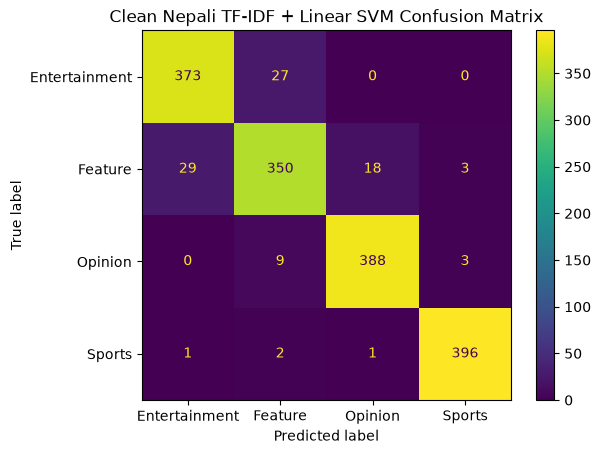

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_clean
)

plt.title("Clean Nepali TF-IDF + Linear SVM Confusion Matrix")
plt.show()

# Conclusion

This project compared three traditional machine learning models for Nepali news classification: Logistic Regression, Multinomial Naive Bayes, and Linear SVM.

Among the baseline models, Linear SVM achieved the highest accuracy of 92.31%.

Further investigation revealed that the initial feature representation contained fragmented and noisy Nepali tokens. A custom Nepali-aware tokenizer was developed using whitespace-based tokenization and basic punctuation cleaning.

Using the improved preprocessing approach, Linear SVM achieved a final accuracy of 94.19%, reducing the number of incorrect predictions from 123 to 93.

The results suggest that preprocessing designed to better preserve complete Nepali words can improve both model performance and feature interpretability.

Feature remained the most challenging category, with frequent confusion with Entertainment and Opinion, while Sports was the easiest category to classify.